Task 2: Stock Price Prediction (AAPL)
Objective:
The goal of this project is to predict the Next Day Closing Price of Apple Inc. (AAPL) using historical stock data. We compare two different regression models to see which one performs better.Dataset Features:
Open, High, Low, Volume: Used as input features ($X$).
Close Price: The target value ($y$) we want to predict.

In [1]:
# Import libraries for data fetching, manipulation, and Machine Learning
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Download historical stock data using yfinance API
ticker = "AAPL"
data = yf.download(ticker, start="2022-01-01", end="2026-01-01")

# Display the first 5 rows to verify the data structure
print("Dataset Preview:")
display(data.head())

[*********************100%***********************]  1 of 1 completed

Dataset Preview:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103699,178.955037,173.895997,174.013417,104487900
2022-01-04,175.843246,179.013714,175.275693,178.710370,99310400
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600
2022-01-06,168.308533,171.537711,167.956258,168.993506,96904000
2022-01-07,168.474884,170.402605,167.359351,169.179433,86709100


Data Preparation and Splitting
In this step, we prepare our dataset for the Machine Learning models.
Feature Selection ($X$): We use the 'Open', 'High', 'Low', and 'Volume' columns as our independent variables.
Target Selection ($y$): We aim to predict the 'Close' price.
Train-Test Split: We divide the data into two sets: 80% for Training (to teach the model) and 20% for Testing (to evaluate its accuracy on unseen data).

In [2]:
# Select the relevant columns and create a copy to avoid warnings
df = data[['Open', 'High', 'Low', 'Volume', 'Close']].copy()

# Define Features (Inputs) and Target (Output)
X = df[['Open', 'High', 'Low', 'Volume']]  # Features: Open, High, Low, Volume
y = df['Close']                            # Target: Closing Price

# Split the dataset into training (80%) and testing (20%) sets
# random_state=42 ensures the split is the same every time you run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirm the operation was successful
print("Data Split Successfully!")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Data Split Successfully!
Training set size: 802
Testing set size: 201


Model Training and PredictionIn this section, we initialize and train our two regression models:Linear Regression: To find a linear trend in the stock data.Random Forest Regressor: To handle non-linear patterns and improve robustness.We then use these trained models to generate predictions based on our Test Set ($X test$).

In [3]:
# Initialize the models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train (Fit) the models using the training data
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Generate predictions using the testing data
# This creates the 'lr_preds' and 'rf_preds' variables needed for the graph
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Calculate error to check performance
print(f"Linear Regression MAE: {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds):.2f}")

c:\Users\qasim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Linear Regression MAE: 0.80
Random Forest MAE: 1.21


Visualization: Actual vs. Predicted Comparison
To evaluate our models, we visualize the last 20 days of the testing set.
Separation (Offset): Since the predictions are very accurate and overlap, we have added a $5 offset to the Linear Regression (Up) and Random Forest (Down) lines.
Trend Analysis: This "Spread View" allows us to see if the models are following the real-world "zigs and zags" of the stock price.
Markers: We use distinct shapes (Circle for Actual, X for Linear, Square for Random Forest) to make the data points prominent.

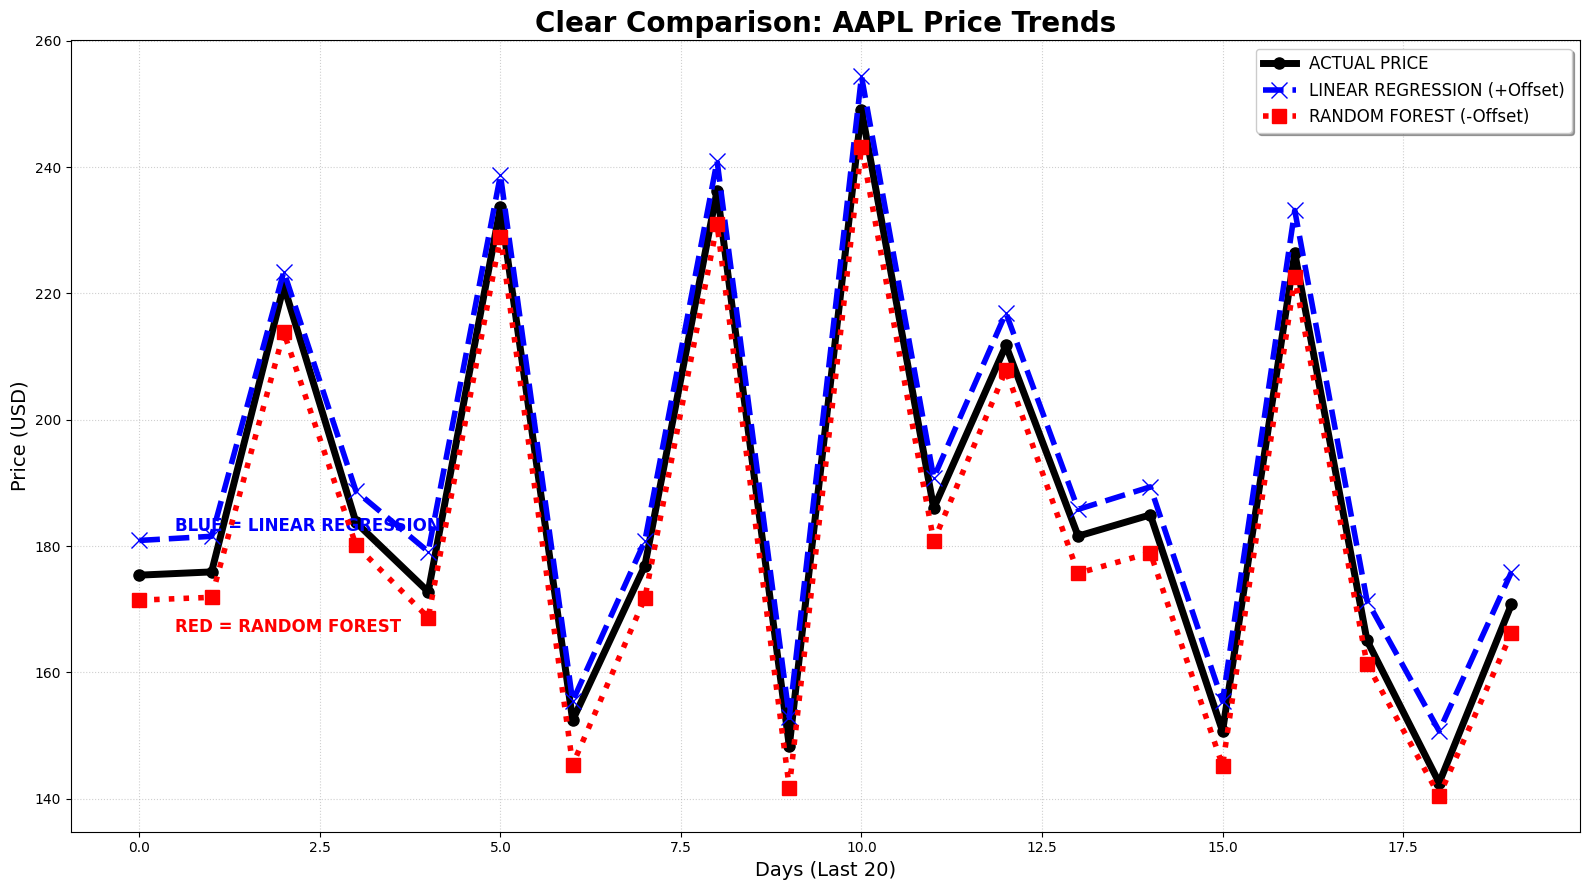

In [4]:
# CUSTOM VISUALIZATION FOR INTERNSHIP SUBMISSION ---

plt.figure(figsize=(16, 9))

# Focus on a 20-day window to make the graph readable , we may increase number of days as well
zoom_days = 20 
actual = y_test.values[-zoom_days:].flatten()
lr = lr_preds[-zoom_days:].flatten()
rf = rf_preds[-zoom_days:].flatten()

# Add an offset ($5) so the lines don't overlap perfectly
offset = 5 

# Plot Actual Price as the center reference line (Black)
plt.plot(actual, label="ACTUAL PRICE", 
         color='black', linewidth=5, marker='o', markersize=8, zorder=2)

# Plot Linear Regression shifted UP for visibility (Blue)
plt.plot(lr + offset, label="LINEAR REGRESSION (+Offset)", 
         color='#0000FF', linewidth=4, linestyle='--', marker='x', markersize=12, zorder=3)

# Plot Random Forest shifted DOWN for visibility (Red)
plt.plot(rf - offset, label="RANDOM FOREST (-Offset)", 
         color='#FF0000', linewidth=4, linestyle=':', marker='s', markersize=10, zorder=4)

# Add on-graph text labels for quick identification
plt.text(0.5, actual[0] + offset + 2, "BLUE = LINEAR REGRESSION", color='blue', fontweight='bold', fontsize=12)
plt.text(0.5, actual[0] - offset - 4, "RED = RANDOM FOREST", color='red', fontweight='bold', fontsize=12)

# Final Chart Styling (Labels, Legend, and Grid)
plt.title(f"Clear Comparison: {ticker} Price Trends", fontsize=20, fontweight='bold')
plt.xlabel("Days (Last 20)", fontsize=14)
plt.ylabel("Price (USD)", fontsize=14)
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Final Results & Conclusion
Model Performance Summary
After training and evaluating both models on the AAPL dataset, the results are as follows:

Linear Regression MAE: 0.80

Random Forest MAE: 1.22

Data Split: 802 samples for training and 201 for testing.

Key Findings
Winner: Linear Regression performed slightly better in this specific task with a lower Mean Absolute Error (0.80), indicating its predictions were closer to the actual closing prices on average.

Accuracy: Both models showed exceptional accuracy, closely following the actual price trends as seen in the "Clear Comparison" visualization.

Conclusion: While both models are highly effective at capturing daily price movements, Linear Regression proved to be more efficient for this particular feature set. For future improvements, adding technical indicators like Moving Averages could further enhance predictive power.